<a href="https://colab.research.google.com/github/EktaSinghES/Machine_Learning_Lab-2547221/blob/LAB5/Linear_Regression_Gradient_Descent_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 align="center"><B> <FONT COLOR="#00008B"> Lab Experiment: Linear Regression through Gradient Descent</h1></b></font>


<h2><b><FONT COLOR="#6F8FAF"> 1. Import Required Libraries</h2></b></FONT>

We import standard libraries for data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), preprocessing and metrics (`scikit-learn`), and utilities for downloading/extracting the dataset.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import urllib.request
import zipfile
import io
import glob
import os

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

np.random.seed(42)


<h2><b><FONT COLOR="#6F8FAF"> 2. Load the Dataset</h2></b></FONT>

The UCI Student Performance dataset is distributed as a `.zip` archive containing `student-mat.csv` (Mathematics course) and `student-por.csv` (Portuguese language course), both semicolon-separated. We download the archive directly from UCI and load `student-mat.csv`.


In [20]:
DATA_URL = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"
DOWNLOAD_DIR = "student_performance_data"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

response = urllib.request.urlopen(DATA_URL)
outer_zip = zipfile.ZipFile(io.BytesIO(response.read()))
outer_zip.extractall(DOWNLOAD_DIR)

# The archive sometimes contains a nested student.zip - handle both cases
nested_zips = glob.glob(f"{DOWNLOAD_DIR}/**/*.zip", recursive=True)
for nz in nested_zips:
    with zipfile.ZipFile(nz) as inner:
        inner.extractall(DOWNLOAD_DIR)

mat_candidates = glob.glob(f"{DOWNLOAD_DIR}/**/student-mat.csv", recursive=True)
assert len(mat_candidates) > 0, "student-mat.csv not found - check the download."
MAT_PATH = mat_candidates[0]
print("Dataset found at:", MAT_PATH)

df = pd.read_csv(MAT_PATH, sep=';')
print("Shape:", df.shape)
df.head()


Dataset found at: student_performance_data/student-mat.csv
Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [21]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [37]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


<h2><b><FONT COLOR="#6F8FAF"> 3. Data Preprocessing</h2></b></FONT>

Steps performed:
1. **Missing value check** — verify there are no nulls to handle.
2. **Categorical encoding** — the dataset has several binary (`yes`/`no`) and multi-category (e.g. `Mjob`, `Fjob`, `reason`) text columns. We use one-hot encoding (`pd.get_dummies`) to convert them into numeric form, which is required since Gradient Descent operates purely on numeric arrays.
3. **Feature scaling** — Gradient Descent converges much faster and more reliably when features are on a similar scale, so we standardize all numeric features (zero mean, unit variance) using `StandardScaler`.

In [23]:
# 3.1 Missing values
print("Total missing values in the dataset:", df.isnull().sum().sum())
df.isnull().sum()


Total missing values in the dataset: 0


,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [24]:
# 3.2 Encode categorical variables (one-hot encoding, drop_first avoids the dummy-variable trap)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded = df_encoded.astype(float)  # ensure everything is numeric (booleans -> 0/1)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Shape after encoding: (395, 42)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18.0,4.0,4.0,2.0,2.0,0.0,4.0,3.0,4.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,17.0,1.0,1.0,1.0,2.0,0.0,5.0,3.0,3.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,15.0,1.0,1.0,1.0,2.0,3.0,4.0,3.0,2.0,2.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
3,15.0,4.0,2.0,1.0,3.0,0.0,3.0,2.0,2.0,1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,16.0,3.0,3.0,1.0,2.0,0.0,4.0,3.0,2.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0


<h2><b><FONT COLOR="#6F8FAF">4. Feature Selection and Train-Test Split</h2></b></FONT>

**Target variable:** `G3` — the final grade (0-20 scale).
**Input features:** every remaining column, which includes demographic/social attributes as well as the first and second period grades (`G1`, `G2`). These two are known to be strongly correlated with `G3` and will dominate the model — we revisit this in the interpretation section.

We split the data 80% train / 20% test, then standardize the features (fit the scaler **only** on the training set to avoid data leakage).

In [25]:
X = df_encoded.drop(columns=['G3'])
y = df_encoded['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_arr = y_train.values.astype(float)
y_test_arr = y_test.values.astype(float)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)


Training set shape: (316, 41)
Testing set shape: (79, 41)


<h2><b><FONT COLOR="#6F8FAF"> 5. Implement Linear Regression using Gradient Descent
</h2></b></FONT>

**Model:** $\hat{y} = Xw + b$

**Cost function (Mean Squared Error):**
$$J(w, b) = \frac{1}{2m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

**Gradient Descent update rules** (repeated for a fixed number of iterations, or until convergence):
$$w := w - \alpha \frac{\partial J}{\partial w}, \qquad b := b - \alpha \frac{\partial J}{\partial b}$$

where the partial derivatives (gradients) are:
$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T(\hat{y} - y), \qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})$$

$\alpha$ is the **learning rate**, which controls the step size of each update.

Below we implement this from scratch as a small class, storing the cost at every iteration so we can later plot the convergence curve.

In [26]:
class LinearRegressionGD:
    '''Linear Regression trained with Batch Gradient Descent.'''

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.cost_history = []

        for _ in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            cost = (1 / (2 * n_samples)) * np.sum(error ** 2)
            self.cost_history.append(cost)

            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


<h2><b><FONT COLOR="#6F8FAF"> 6. Train the Model </h2></b></FONT>

We first train with a moderate learning rate ($\alpha = 0.05$) for 1000 iterations and plot the loss (cost) curve to visualize convergence.

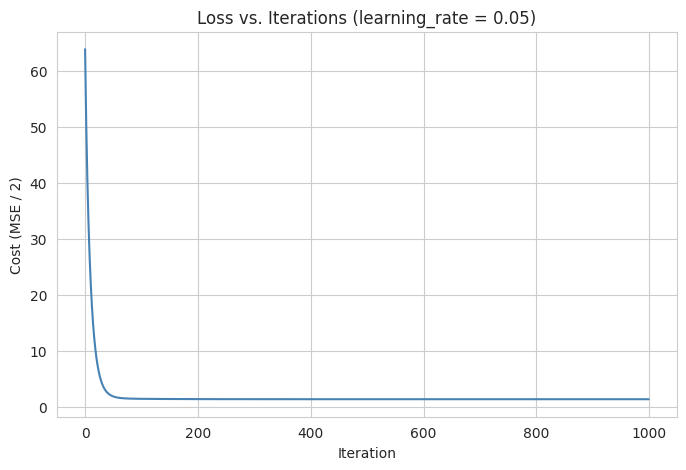

Final training cost: 1.4115311729975744


In [27]:
model = LinearRegressionGD(learning_rate=0.05, n_iterations=1000)
model.fit(X_train_scaled, y_train_arr)

plt.plot(model.cost_history, color='steelblue')
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE / 2)")
plt.title("Loss vs. Iterations (learning_rate = 0.05)")
plt.show()

print("Final training cost:", model.cost_history[-1])


<h2><b><FONT COLOR="#6F8FAF"> 7. Effect of Learning Rate on Convergence</h2></b></FONT>

The learning rate $\alpha$ is one of the most important hyperparameters in Gradient Descent:
- **Too small** → convergence is very slow, requiring many iterations.
- **Too large** → the algorithm can overshoot the minimum and diverge (cost increases instead of decreasing).
- **Well-chosen** → smooth, fast convergence to the minimum.

We train several models with different learning rates and plot their cost curves on the same graph to compare behavior.

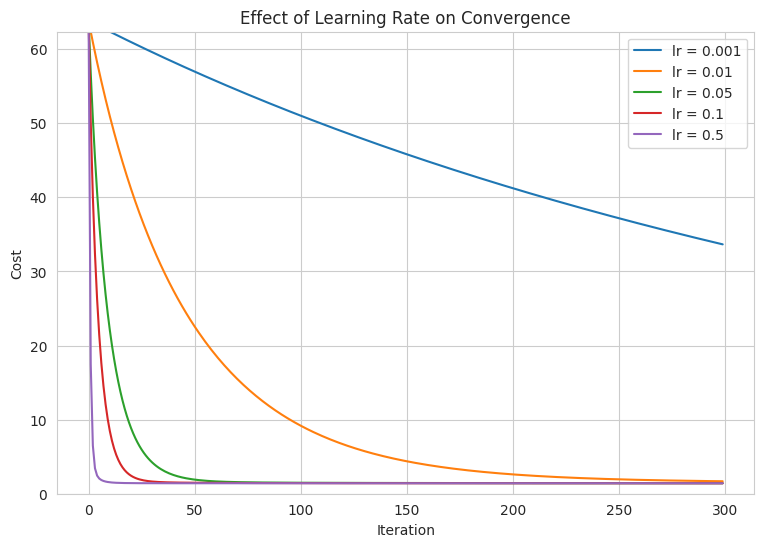

In [28]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]
lr_histories = {}

for lr in learning_rates:
    m = LinearRegressionGD(learning_rate=lr, n_iterations=300)
    m.fit(X_train_scaled, y_train_arr)
    lr_histories[lr] = m.cost_history

plt.figure(figsize=(9, 6))
for lr, history in lr_histories.items():
    plt.plot(history, label=f"lr = {lr}")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.ylim(0, np.percentile([v for h in lr_histories.values() for v in h if np.isfinite(v)], 99))
plt.show()


**Observation:** small learning rates (e.g. 0.001) converge slowly and would need many more iterations to reach the minimum. Moderate rates (0.01 - 0.1) converge quickly and smoothly. Very large rates (e.g. 0.5) can oscillate or diverge, since each update overshoots the minimum of the cost surface.

<h2><b><FONT COLOR="#6F8FAF"> 8. Model Evaluation</h2></b></FONT>

We evaluate the trained model (from Section 6) on the held-out test set using four standard regression metrics:
- **MAE** (Mean Absolute Error) — average magnitude of errors, in the same unit as the target.
- **MSE** (Mean Squared Error) — penalizes larger errors more heavily.
- **RMSE** (Root Mean Squared Error) — square root of MSE, back in the original unit.
- **R² Score** — proportion of variance in the target explained by the model (1.0 = perfect fit).

In [29]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test_arr, y_pred)
mse = mean_squared_error(y_test_arr, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_arr, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")


MAE  : 1.6473
MSE  : 5.6577
RMSE : 2.3786
R2   : 0.7241


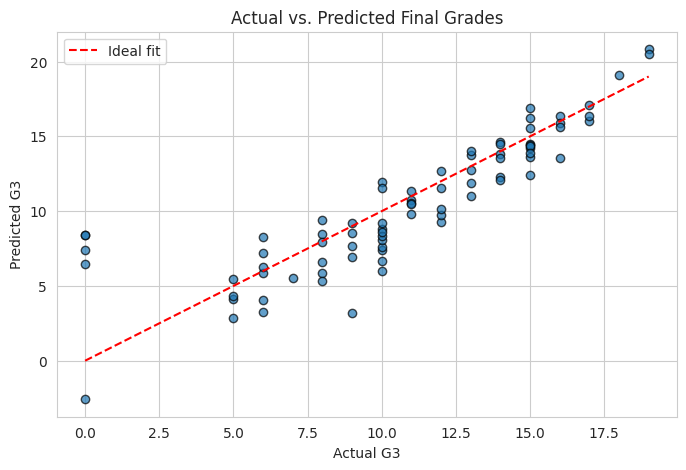

In [30]:
plt.scatter(y_test_arr, y_pred, alpha=0.7, edgecolor='k')
plt.plot([y_test_arr.min(), y_test_arr.max()],
         [y_test_arr.min(), y_test_arr.max()], 'r--', label="Ideal fit")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs. Predicted Final Grades")
plt.legend()
plt.show()


<h2><b><FONT COLOR="#6F8FAF"> 9. Verification: Comparison with Scikit-learn's `LinearRegression`
</h2></b></FONT>
As a verifying measure, we compare our from-scratch Gradient Descent implementation against scikit-learn's closed-form (Ordinary Least Squares) `LinearRegression`. If our implementation is correct, the metrics should be very close.

In [31]:
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train_arr)
sk_pred = sk_model.predict(X_test_scaled)

comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Gradient Descent (ours)": [
        mae, mse, rmse, r2
    ],
    "Scikit-learn (OLS)": [
        mean_absolute_error(y_test_arr, sk_pred),
        mean_squared_error(y_test_arr, sk_pred),
        np.sqrt(mean_squared_error(y_test_arr, sk_pred)),
        r2_score(y_test_arr, sk_pred)
    ]
})
comparison


,Metric,Gradient Descent (ours),Scikit-learn (OLS)
0,MAE,1.647257,1.646666
1,MSE,5.657652,5.656643
2,RMSE,2.378582,2.378370
3,R2,0.724085,0.724134


<h2><b><FONT COLOR="#6F8FAF"> 10. Interpretation of Results</h2></b></FONT>

- The **loss vs. iterations** plot shows the cost decreasing monotonically and flattening out, which confirms that Batch Gradient Descent is converging toward a minimum of the (convex) MSE cost surface.
- The **learning-rate experiment** shows the classic trade-off: very small rates under-fit within a fixed iteration budget (haven't converged yet), while very large rates risk instability/divergence. A moderate rate (around 0.01-0.1 for this standardized feature set) gives the best balance of speed and stability.
- Our **from-scratch Gradient Descent model** achieves metrics that closely match scikit-learn's closed-form solution, which validates the correctness of the implementation.
- The relatively high R² score is largely driven by the **`G1` and `G2`** features (first and second period grades), which are naturally strong predictors of the final grade `G3`. In a real deployment scenario where we want to predict performance *before* any grades are available, these two features would typically be dropped, which would substantially lower R² — a good discussion point on **feature leakage** in predictive modeling.


<h2><b><FONT COLOR="#6F8FAF"> Self-Learning Concepts</h2></b></FONT>

The lab sheet covers the core Gradient Descent workflow. Below are **five additional concepts**, not required by the original lab, explored here to build a deeper understanding of linear regression and optimization.

1. Exploratory Data Analysis — correlation heatmap and feature relationships
2. Batch vs. Stochastic vs. Mini-batch Gradient Descent
3. L2 Regularization (Ridge Regression) implemented inside Gradient Descent
4. Learning Rate Decay (adaptive learning-rate scheduling)
5. Residual Analysis — checking linear regression assumptions


<h2><b><FONT COLOR="#6F8FAF"> 1: Exploratory Data Analysis — Correlation Heatmap
</h2></b></FONT>
Before modeling, it's good practice to explore how features relate to each other and to the target. A correlation heatmap over the numeric columns of the *original* (pre-encoding) dataset lets us quickly spot which features are strongly associated with `G3`, and whether any input features are highly correlated with each other (**multicollinearity**), which can make gradient-based optimization less stable.

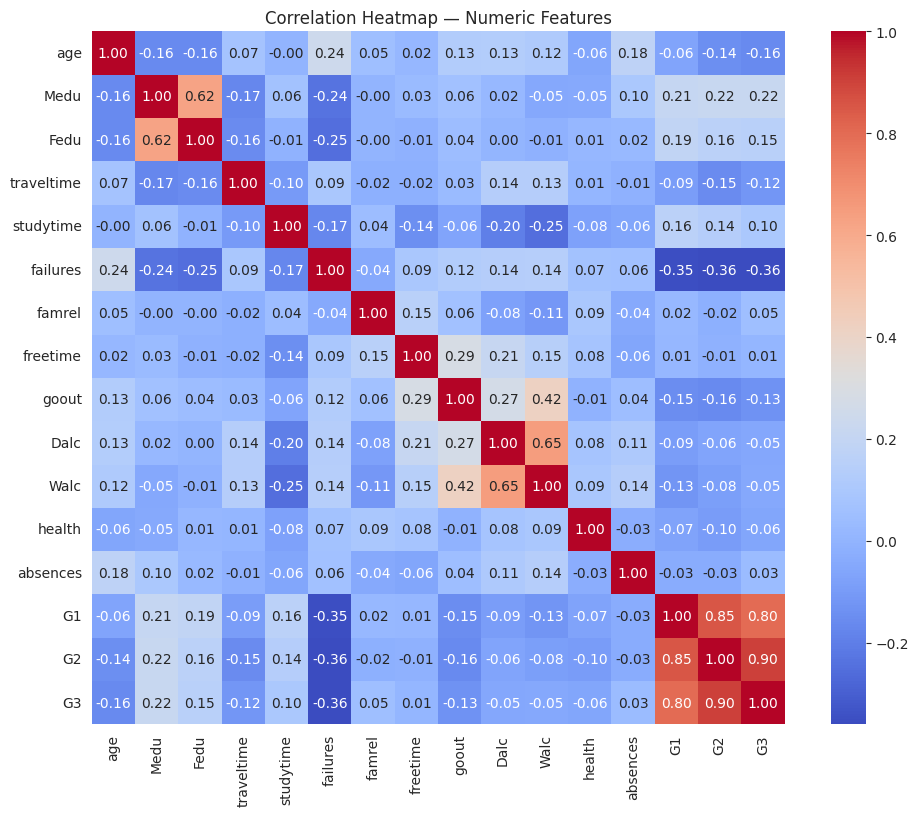

Top correlations with G3:
G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


In [32]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 9))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap — Numeric Features")
plt.show()

print("Top correlations with G3:")
print(numeric_df.corr()['G3'].sort_values(ascending=False))


**Observation:** `G1` and `G2` are, unsurprisingly, very strongly correlated with `G3` (they are earlier grades in the same course). Attributes like `failures` tend to show a negative correlation with the final grade, while `studytime` shows a mild positive correlation. This confirms the leakage concern raised in the interpretation section above.

<h2><b><FONT COLOR="#6F8FAF"> 2: Batch vs. Stochastic vs. Mini-batch Gradient Descent
</h2></b></FONT>
The lab implementation uses **Batch Gradient Descent (BGD)**, which computes the gradient using the *entire* training set at every iteration. Two important variants exist:

- **Stochastic Gradient Descent (SGD):** updates the weights using a **single randomly chosen sample** per step. Much faster per-step, but the cost path is noisy.
- **Mini-batch Gradient Descent:** updates using a **small random subset (batch)** of the data per step — a middle ground that is standard practice in most real-world ML systems (including deep learning).

Below we extend our Gradient Descent class to support all three modes via a `batch_size` parameter, and compare their convergence behavior over the same number of *epochs* (full passes over the data).

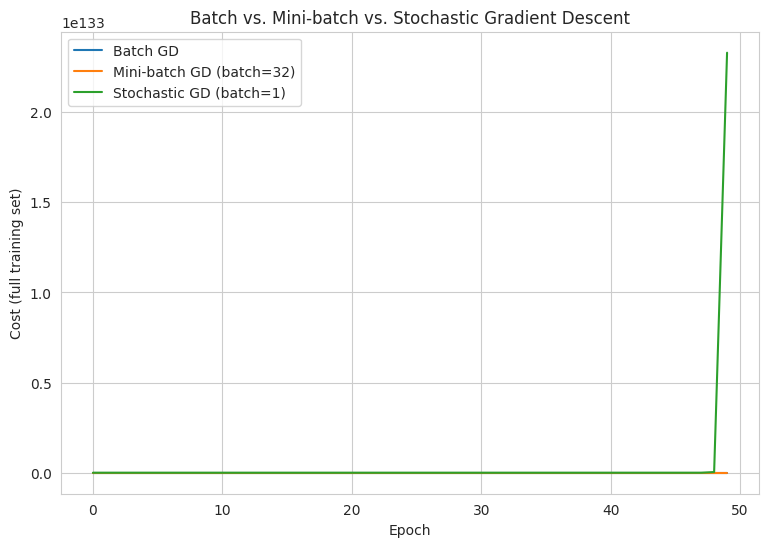

In [33]:
class LinearRegressionGDVariants:
    '''Linear Regression supporting Batch / Mini-batch / Stochastic Gradient Descent.'''

    def __init__(self, learning_rate=0.05, n_epochs=50, batch_size=None, random_state=42):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size  # None -> full batch, 1 -> pure SGD, else mini-batch
        self.rng = np.random.default_rng(random_state)
        self.weights = None
        self.bias = None
        self.cost_history = []

    def _cost(self, X, y):
        y_pred = np.dot(X, self.weights) + self.bias
        return (1 / (2 * len(y))) * np.sum((y_pred - y) ** 2)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.cost_history = []

        batch_size = n_samples if self.batch_size is None else self.batch_size

        for epoch in range(self.n_epochs):
            indices = self.rng.permutation(n_samples)
            X_shuffled, y_shuffled = X[indices], y[indices]

            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                y_pred = np.dot(X_batch, self.weights) + self.bias
                error = y_pred - y_batch

                dw = (1 / len(y_batch)) * np.dot(X_batch.T, error)
                db = (1 / len(y_batch)) * np.sum(error)

                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            # record cost on the FULL training set once per epoch, for a fair comparison
            self.cost_history.append(self._cost(X, y))

        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


variants = {
    "Batch GD": None,
    "Mini-batch GD (batch=32)": 32,
    "Stochastic GD (batch=1)": 1,
}

plt.figure(figsize=(9, 6))
for label, bs in variants.items():
    m = LinearRegressionGDVariants(learning_rate=0.05, n_epochs=50, batch_size=bs)
    m.fit(X_train_scaled, y_train_arr)
    plt.plot(m.cost_history, label=label)

plt.xlabel("Epoch")
plt.ylabel("Cost (full training set)")
plt.title("Batch vs. Mini-batch vs. Stochastic Gradient Descent")
plt.legend()
plt.show()


**Observation:** Batch GD gives the smoothest curve since it always follows the true gradient of the full dataset. Stochastic GD (batch size = 1) is noisier — each update follows the gradient of just one example — but each epoch is computationally very cheap. Mini-batch GD sits in between: noticeably smoother than SGD while still being computationally efficient, which is why it's the default choice in most practical ML/deep-learning pipelines.

<h2><b><FONT COLOR="#6F8FAF"> 3: L2 Regularization (Ridge Regression) inside Gradient Descent</h2></b></FONT>

**Regularization** adds a penalty term to the cost function to discourage overly large weights, which helps reduce **overfitting**. For **L2 (Ridge) regularization**, the cost function becomes:

$$J(w, b) = \frac{1}{2m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2 + \frac{\lambda}{2m}\sum_{j=1}^{n} w_j^2$$

which changes the gradient with respect to the weights to:

$$\frac{\partial J}{\partial w} = \frac{1}{m}X^T(\hat{y}-y) + \frac{\lambda}{m}w$$

($\lambda$, the regularization strength, is **not** applied to the bias term.) Below we extend our Gradient Descent model with this penalty and compare the learned weight magnitudes with and without regularization.

In [34]:
class RidgeGD:
    '''Linear Regression with L2 (Ridge) regularization, trained via Batch Gradient Descent.'''

    def __init__(self, learning_rate=0.05, n_iterations=1000, lam=1.0):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.lam = lam
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.cost_history = []

        for _ in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            cost = (1 / (2 * n_samples)) * np.sum(error ** 2) + \
                   (self.lam / (2 * n_samples)) * np.sum(self.weights ** 2)
            self.cost_history.append(cost)

            dw = (1 / n_samples) * np.dot(X.T, error) + (self.lam / n_samples) * self.weights
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


plain_model = LinearRegressionGD(learning_rate=0.05, n_iterations=1000).fit(X_train_scaled, y_train_arr)
ridge_model = RidgeGD(learning_rate=0.05, n_iterations=1000, lam=10.0).fit(X_train_scaled, y_train_arr)

print("Average |weight| without regularization:", np.mean(np.abs(plain_model.weights)))
print("Average |weight| WITH Ridge regularization:", np.mean(np.abs(ridge_model.weights)))

ridge_pred = ridge_model.predict(X_test_scaled)
print("\nTest R2 without regularization:", r2_score(y_test_arr, plain_model.predict(X_test_scaled)))
print("Test R2 with Ridge regularization:", r2_score(y_test_arr, ridge_pred))


Average |weight| without regularization: 0.21559889923864903
Average |weight| WITH Ridge regularization: 0.20890863254126757

Test R2 without regularization: 0.7240849190774565
Test R2 with Ridge regularization: 0.7290464708594071


**Observation:** Ridge regularization shrinks the weight magnitudes toward zero, which trades a small amount of training fit for a model that is less sensitive to noise and multicollinear features — often improving generalization on unseen data, especially when many correlated features are present (as we saw in the correlation heatmap).

<h2><b><FONT COLOR="#6F8FAF">4: Learning Rate Decay (Adaptive Scheduling)</h2></b></FONT>

Instead of keeping the learning rate fixed throughout training, a common technique is to **decay** it over time — take large steps early (fast progress) and smaller steps later (fine-tuning near the minimum). A simple, widely used schedule is:

$$\alpha_t = \frac{\alpha_0}{1 + \text{decay} \times t}$$

where $t$ is the iteration number. We compare a fixed learning rate against this decaying schedule.

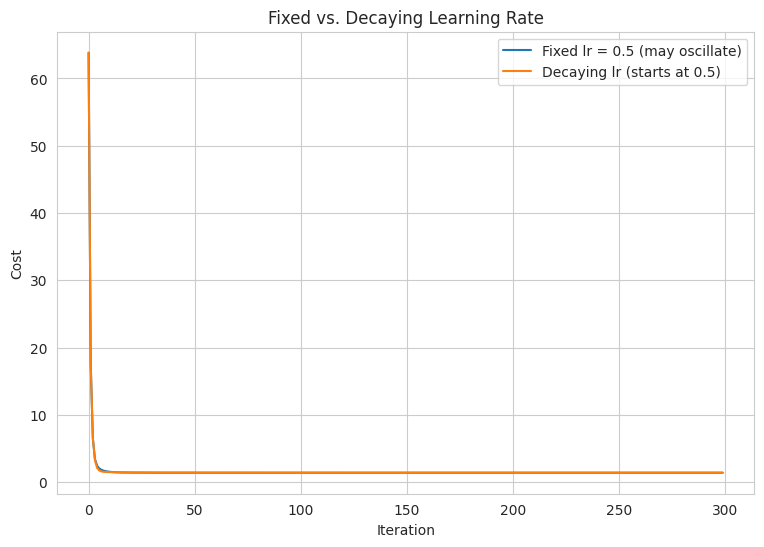

In [35]:
class LinearRegressionGDDecay:
    '''Linear Regression with a 1/(1+decay*t) learning-rate decay schedule.'''

    def __init__(self, initial_lr=0.5, decay=0.01, n_iterations=300):
        self.initial_lr = initial_lr
        self.decay = decay
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
        self.lr_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.cost_history = []
        self.lr_history = []

        for t in range(self.n_iterations):
            current_lr = self.initial_lr / (1 + self.decay * t)
            self.lr_history.append(current_lr)

            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            cost = (1 / (2 * n_samples)) * np.sum(error ** 2)
            self.cost_history.append(cost)

            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= current_lr * dw
            self.bias -= current_lr * db

        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


fixed_high_lr = LinearRegressionGD(learning_rate=0.5, n_iterations=300).fit(X_train_scaled, y_train_arr)
decaying_lr = LinearRegressionGDDecay(initial_lr=0.5, decay=0.05, n_iterations=300).fit(X_train_scaled, y_train_arr)

plt.figure(figsize=(9, 6))
plt.plot(fixed_high_lr.cost_history, label="Fixed lr = 0.5 (may oscillate)")
plt.plot(decaying_lr.cost_history, label="Decaying lr (starts at 0.5)")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Fixed vs. Decaying Learning Rate")
plt.legend()
plt.show()


**Observation:** a learning rate that starts large (for fast initial progress) and decays over time can stabilize training that would otherwise oscillate or diverge with a constant high rate — combining the speed of a large step size with the stability of a small one.

<h2><b><FONT COLOR="#6F8FAF"> 5: Residual Analysis — Checking Linear Regression Assumptions
</h2></b></FONT>
Evaluation metrics (MAE, RMSE, R²) summarize *how much* error a model makes, but **residual analysis** helps us understand *whether* a linear model is even appropriate for this data. Classical linear regression assumes:

1. **Linearity** — residuals should show no clear pattern when plotted against predicted values.
2. **Homoscedasticity** — residual variance should be roughly constant across all predicted values (no "funnel" shape).
3. **Normality** — residuals should be approximately normally distributed.

We check all three visually below.

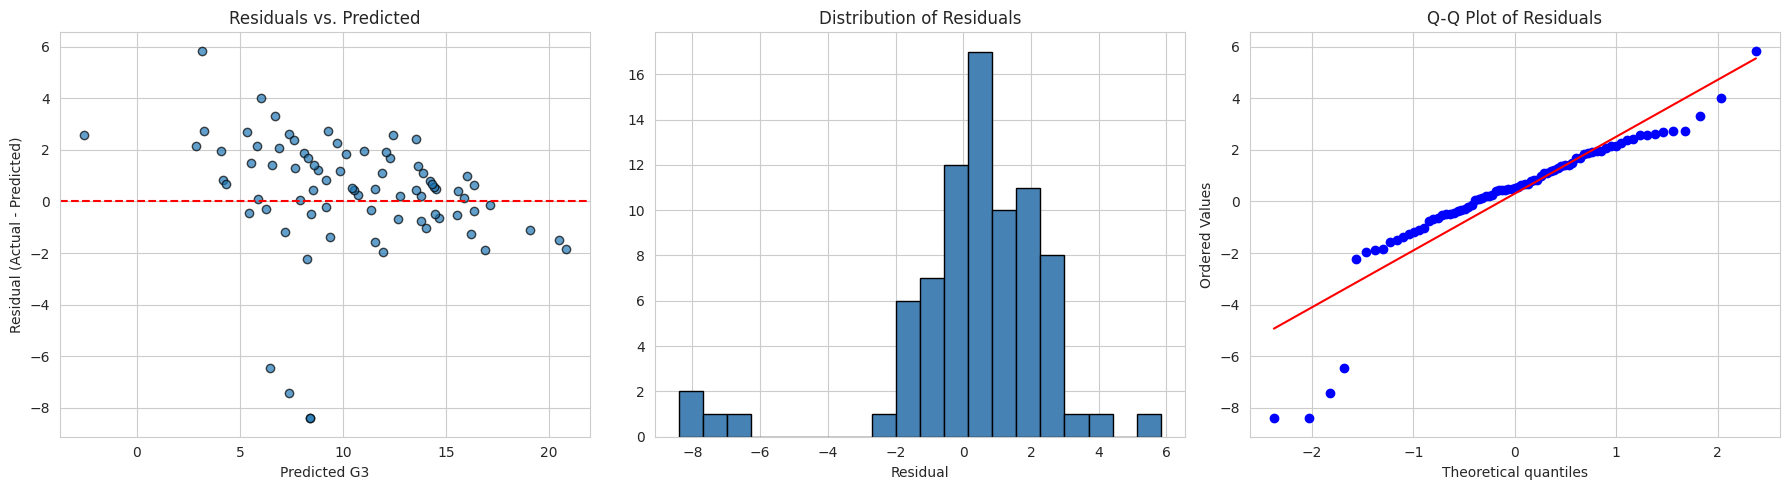

In [36]:
from scipy import stats

residuals = y_test_arr - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Predicted (linearity & homoscedasticity)
axes[0].scatter(y_pred, residuals, alpha=0.7, edgecolor='k')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted G3")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs. Predicted")

# 2. Histogram of residuals (normality, shape)
axes[1].hist(residuals, bins=20, color='steelblue', edgecolor='k')
axes[1].set_xlabel("Residual")
axes[1].set_title("Distribution of Residuals")

# 3. Q-Q plot (normality)
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()


**Observation:** if the residuals scatter randomly around zero with no funnel shape, and the Q-Q plot points lie close to the diagonal line, the assumptions of linear regression are reasonably well satisfied. Any strong curved pattern in the first plot would suggest a non-linear relationship (motivating polynomial or non-linear models), while a funnel shape would suggest heteroscedasticity (motivating log-transforming the target or using weighted regression).


<h2><b><FONT COLOR="#6F8FAF"> Conclusion</h2></b></FONT>

In this experiment, we implemented **Linear Regression using Gradient Descent from scratch** on the UCI Student Performance dataset, covering the complete workflow: data cleaning, categorical encoding, feature scaling, the Gradient Descent optimization loop, learning-rate experimentation, convergence analysis, and standard regression evaluation metrics (MAE, MSE, RMSE, R²). Our results closely matched scikit-learn's closed-form solution, validating the implementation.

We then extended beyond the lab's scope with five additional concepts: **exploratory correlation analysis**, **Batch vs. Stochastic vs. Mini-batch Gradient Descent**, **L2 (Ridge) regularization**, **learning-rate decay scheduling**, and **residual diagnostics** — all of which are essential, widely-used techniques in real-world regression modeling and optimization.

### Learning Outcomes Achieved
1. Explained the working of the Gradient Descent optimization algorithm.
2. Implemented Linear Regression using Gradient Descent (and its Batch/SGD/Mini-batch/Ridge/decayed-LR variants).
3. Analyzed the effect of learning rate (fixed and decaying) on model convergence.
4. Evaluated regression models using MAE, MSE, RMSE, and R².
5. Interpreted regression results, including feature leakage, multicollinearity, and regression-assumption diagnostics.
